In [3]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [73]:
x,y = make_regression(n_samples = 100, n_features = 2, n_informative = 2, noise= 50)

In [74]:
df = pd.DataFrame({'feature1':x[:,0], "feature2":x[:,1], 'target':y})

In [75]:
df.head()

,feature1,feature2,target
0,-0.468691,0.472877,10.529346
1,-0.684545,0.419497,-48.177355
2,0.557079,-0.913595,3.255721
3,-1.309384,0.842823,-63.001075
4,0.220115,-0.278813,67.228933


In [76]:
df.shape

(100, 3)

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state = 2)

In [79]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z = 'target')

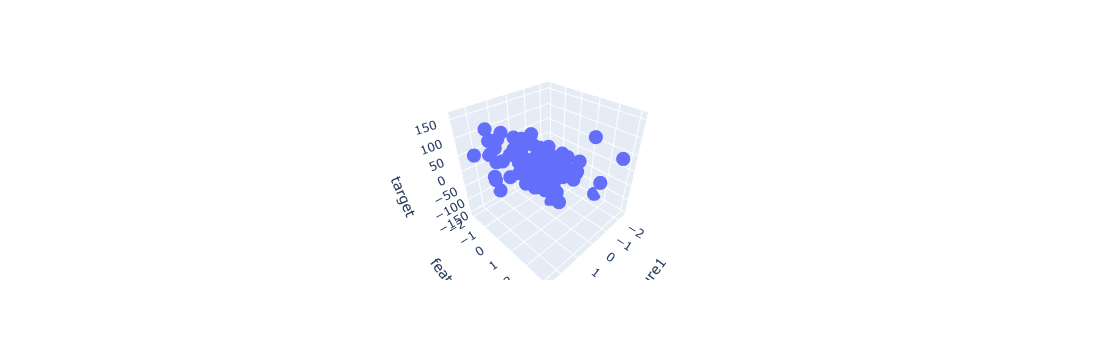

In [80]:
fig.show()

In [81]:
from sklearn.linear_model import LinearRegression

In [82]:
lr = LinearRegression()

In [83]:
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
y_pred = lr.predict(x_test)

In [85]:
print('MAE', mean_absolute_error(y_test, y_pred))
print('MSE', mean_squared_error(y_test, y_pred))
print('R2 score', r2_score(y_test, y_pred))

MAE 44.82665833932242
MSE 2831.692559014723
R2 score 0.22982033319459683


In [86]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)

z = z_final



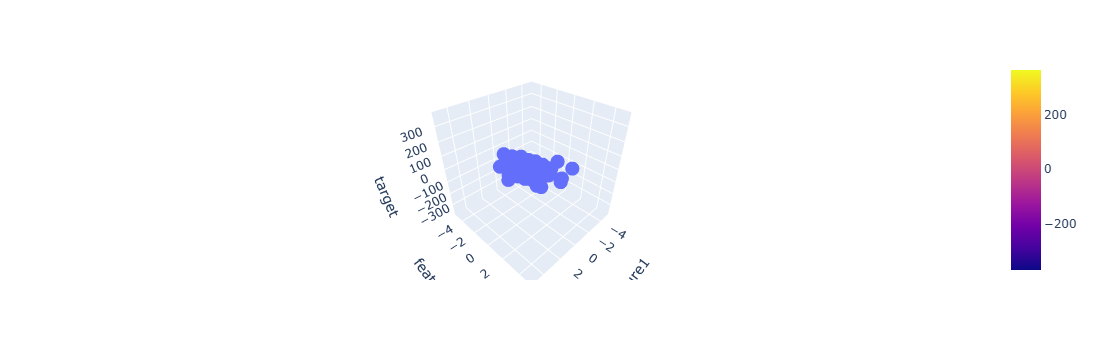

In [87]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target' )

fig.add_trace(go.Surface(x= x, y = y, z =z ))

fig.show()

In [88]:
lr.coef_

array([51.64930215, 21.70550347])

In [89]:
lr.intercept_

np.float64(-3.394868965423349)